O primeiro projeto cobre o pipeline fundamental de deep learning de ponta a ponta. Você escolhe um problema aplicado, constrói um MLP do zero em PyTorch e o leva até um estado de treinamento estável e diagnosticado.

O ponto de partida é o ambiente: PyTorch, Jupyter (ou Google Colab) e TensorBoard configurados e verificados antes de qualquer treinamento. A partir daí, você implementa o MLP usando nn.Module, definindo explicitamente cada camada, função de ativação e forward pass, sem abstrações de alto nível como PyTorch Lightning. A arquitetura não é arbitrária: você justifica a escolha de profundidade e largura em relação ao problema, analisa empiricamente o efeito de pelo menos duas funções de ativação diferentes nas curvas de loss e documenta o impacto da inicialização de pesos (Xavier ou He) comparada à inicialização padrão do PyTorch.

O training loop deve incluir DataLoader, ciclo de validação por época e checkpointing via state_dict que permite recarregar o melhor modelo e reproduzir predições. Além do problema de classificação, você implementa uma variante de regressão com MSE loss e avalia com MAE, RMSE e R². A estabilidade do treinamento é tratada como requisito, não como bônus: você analisa gradient norms para diagnosticar vanishing ou exploding gradients, implementa BatchNorm ou LayerNorm comparando o efeito nas curvas de loss, aplica Dropout verificando o impacto no gap treino/validação e configura Adam ou AdamW com learning rate scheduling monitorado no TensorBoard.

O relatório cobre o diagnóstico completo do treinamento. Para as métricas, use o conjunto de teste, não o de validação, e documente um baseline não trivial para referência. As curvas de loss devem ser analisadas com nome explícito para o fenômeno observado (overfitting, underfitting, instabilidade ou convergência). Ao menos um problema real identificado nos seus experimentos deve ser descrito com hipótese formulada antes da correção, correção aplicada e efeito medido: gradient norm, spike de loss ou distribuição de ativações como evidência objetiva. Para classificação, inclua a interpretação da matriz de confusão com hipótese sobre os padrões de erro observados no seu dado específico

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


# Configuração de sementes para reprodutibilidade estrita
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cpu


In [2]:
# Carregar dataset bruto
df_raw = pd.read_csv('../data/penguins_lter.csv')

print(f"📊 Dimensão original do dataset: {df_raw.shape} (linhas, colunas)\n")
print("🔍 Primeiras 5 linhas do DataFrame:")
display(df_raw.head())

print("\nℹ️ Informações sobre tipos de dados:")
df_raw.info()

📊 Dimensão original do dataset: (344, 17) (linhas, colunas)

🔍 Primeiras 5 linhas do DataFrame:


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN



ℹ️ Informações sobre tipos de dados:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o

In [3]:
df_raw['Sex'] = df_raw['Sex'].replace('.', np.nan)
df = df_raw.dropna(subset=['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)','Body Mass (g)','Sex']).copy()

print(f"\n🧹 Dimensão após remover alvos ausentes: {df.shape}")



🧹 Dimensão após remover alvos ausentes: (333, 17)


removendo colunas irrelevantes e  escolhendo meu target de classificação.

In [4]:
# Separar atributos preditivos (X) e variável alvo (y)
X_raw = df.drop(columns=['Delta 15 N (o/oo)','Delta 13 C (o/oo)','studyName', 'Sample Number', 'Individual ID', 'Date Egg', 'Comments', 'Stage','Region','Species','Clutch Completion'])
species_raw_labels = df['Species'].values

print(f"📊 Dimensão de X_raw: {X_raw.shape}")
# Codificação da variável alvo
label_encoder = LabelEncoder()
species_encoded = label_encoder.fit_transform(species_raw_labels)


📊 Dimensão de X_raw: (333, 6)


In [5]:

# Exibir o mapeamento das classes
class_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print(f"🏷️ Mapeamento de Classes: {class_mapping}")

# print("\n👀 Amostra dos primeiros 10 rótulos codificados:")
# for label_text, label_num in zip(y_raw_labels[:10], y_encoded[:10]):
#     print(f"   • '{label_text}' ➔ {label_num}")

🏷️ Mapeamento de Classes: {'Adelie Penguin (Pygoscelis adeliae)': 0, 'Chinstrap penguin (Pygoscelis antarctica)': 1, 'Gentoo penguin (Pygoscelis papua)': 2}


In [6]:
# 1º Passo: Separar Treino (70%) e Conjunto Temporário (30%)
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_raw, species_encoded, test_size=0.30, random_state=42, stratify=species_encoded
)

# 2º Passo: Dividir o Temporário igualmente em Validação (15%) e Teste (15%)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [7]:

print(f"📊 Divisão dos dados realizada com sucesso:")
print(f"   • Conjunto de Treino:    {X_train_df.shape[0]} amostras ({X_train_df.shape[0]/len(df)*100:.1f}%)")
print(f"   • Conjunto de Validação: {X_val_df.shape[0]} amostras ({X_val_df.shape[0]/len(df)*100:.1f}%)")
print(f"   • Conjunto de Teste:     {X_test_df.shape[0]} amostras ({X_test_df.shape[0]/len(df)*100:.1f}%)")


📊 Divisão dos dados realizada com sucesso:
   • Conjunto de Treino:    233 amostras (70.0%)
   • Conjunto de Validação: 50 amostras (15.0%)
   • Conjunto de Teste:     50 amostras (15.0%)


In [8]:
# Definir listas de colunas numéricas e categóricas
num_cols = ['Culmen Length (mm)','Culmen Depth (mm)','Flipper Length (mm)','Body Mass (g)']
cat_cols = ['Island', 'Sex']

print("🔍 Visualizando dados brutos de Treino (Antes da Transformação):")
print("\n--- Colunas Numéricas ---")
display(X_train_df[num_cols].head(3))

print("\n--- Colunas Categóricas ---")
display(X_train_df[cat_cols].head(3))

🔍 Visualizando dados brutos de Treino (Antes da Transformação):

--- Colunas Numéricas ---


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
268,44.9,13.3,213.0,5100.0
201,49.8,17.3,198.0,3675.0
321,55.9,17.0,228.0,5600.0



--- Colunas Categóricas ---


,Island,Sex
268,Biscoe,FEMALE
201,Dream,FEMALE
321,Biscoe,MALE


O one-hot encoding: uma coluna categórica não vira 1 coluna numérica, vira várias (uma por
  categoria, menos uma por causa do drop='first').

  Olha o que a célula 9 mostra antes da transformação: num_cols (4: as medidas) + cat_cols (2: Island, Sex) = 6 colunas brutas. É
  esse "6" que você está vendo no Excel/CSV.

  Mas na célula 11, depois do ColumnTransformer, o OneHotEncoder(drop='first') expande cada categórica em N-1 colunas binárias, onde
  N é o número de categorias distintas:
  - Island tem 3 valores possíveis (Biscoe/Dream/Torgersen) → vira 2 colunas (Island_Dream, Island_Torgersen; Biscoe fica implícito
  quando as duas são 0)
  - Sex tem 2 valores (MALE/FEMALE) → vira 1 coluna (Sex_MALE; FEMALE fica implícito quando é 0)

  Então: 4 numéricas + 2 (de Island) + 1 (de Sex) = 7, exatamente o que o print da célula 11 mostrou: Formato da Matriz 
  Pré-processada (X_train): (233, 7), listando as 7 colunas nome a nome.

  Ou seja: 6 é o número de colunas antes de codificar; 7 é o número de colunas depois — e é esse segundo número que importa pra
  arquitetura, porque é o que de fato entra na rede (X_train.shape[1]). Faz sentido, ou você está vendo esse "6" em outro lugar que
  eu não considerei?


In [9]:
# Construir o precessador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False),cat_cols)
    ]
)

In [10]:
 #1. Fit + Transform EXCLUSIVAMENTE no Treino
X_train = preprocessor.fit_transform(X_train_df)

# 2. Apenas Transform na Validação e no Teste
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

# Obter nomes das colunas geradas após o One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

print(f"Formato da Matriz Pré-processada (X_train): {X_train.shape}")
print(f"Nomes das {len(feature_names)} colunas resultantes:")
for i, col in enumerate(feature_names):
    print(f"   [{i:02d}] {col}")

print("\nExemplo das primeiras 2 linhas codificadas de X_train (prontas para o PyTorch):")
print(np.round(X_train[:2], 3))

Formato da Matriz Pré-processada (X_train): (233, 7)
Nomes das 7 colunas resultantes:
   [00] num__Culmen Length (mm)
   [01] num__Culmen Depth (mm)
   [02] num__Flipper Length (mm)
   [03] num__Body Mass (g)
   [04] cat__Island_Dream
   [05] cat__Island_Torgersen
   [06] cat__Sex_MALE

Exemplo das primeiras 2 linhas codificadas de X_train (prontas para o PyTorch):
[[ 0.163 -1.998  0.834  1.083  0.     0.     0.   ]
 [ 1.052  0.023 -0.244 -0.692  1.     0.     0.   ]]


In [11]:
class PinguinsDataSet(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [12]:
train_dataset = PinguinsDataSet(X_train, y_train)
val_dataset = PinguinsDataSet(X_val, y_val)
test_dataset = PinguinsDataSet(X_test, y_test)

# Inspeção de um único exemplo do Dataset
sample_X, sample_y = train_dataset[0]
print(f"📦 Amostra 0 do Dataset:")
print(f"   • Tensor de Atributos (X): formato {sample_X.shape}, tipo {sample_X.dtype}")
print(f"   • Tensor de Rótulo (y): valor {sample_y.item()} (Classe: {label_encoder.classes_[sample_y.item()]}), tipo {sample_y.dtype}")

📦 Amostra 0 do Dataset:
   • Tensor de Atributos (X): formato torch.Size([7]), tipo torch.float32
   • Tensor de Rótulo (y): valor 2 (Classe: Gentoo penguin (Pygoscelis papua)), tipo torch.int64


# 7. Criando os DataLoaders no PyTorch
O DataLoader agrupa amostras do Dataset em lotes (batches), realiza o embaralhamento (shuffle) dos dados de treino a cada época e gerencia o iterador de treinamento.

In [13]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"🚚 DataLoaders criados com batch_size = {batch_size}:")
print(f"   • Lotes de Treino:    {len(train_loader)} batches")
print(f"   • Lotes de Validação: {len(val_loader)} batches")
print(f"   • Lotes de Teste:     {len(test_loader)} batches")

# Inspecionar o primeiro lote do train_loader
first_X_batch, first_y_batch = next(iter(train_loader))
print(f"\n🧩 Inspecionando o primeiro Lote (Batch):")
print(f"   • Formato de X_batch: {first_X_batch.shape} ➔ (batch_size, n_atributos)")
print(f"   • Formato de y_batch: {first_y_batch.shape} ➔ (batch_size,)")

🚚 DataLoaders criados com batch_size = 32:
   • Lotes de Treino:    8 batches
   • Lotes de Validação: 2 batches
   • Lotes de Teste:     2 batches

🧩 Inspecionando o primeiro Lote (Batch):
   • Formato de X_batch: torch.Size([32, 7]) ➔ (batch_size, n_atributos)
   • Formato de y_batch: torch.Size([32]) ➔ (batch_size,)


# 8. Pensando na Arquitetura da MLP

## Entrada e saída da rede (fixas, não são escolha)

- **Entrada = 7 neurônios** — um por coluna de `X_train.shape[1]`, resultado do one-hot explicado acima (4 medidas numéricas + 2 de `Island` + 1 de `Sex`).
- **Saída = 3 neurônios** — um por espécie (`Adelie`/`Chinstrap`/`Gentoo`). Com `nn.CrossEntropyLoss`, a última camada deve devolver **logits crus**, sem `Softmax` aplicado manualmente — a loss já faz `log_softmax` internamente, e aplicar as duas coisas juntas dá resultado errado.

## Profundidade e largura das camadas ocultas (aqui é escolha)

Com só 233 exemplos de treino, o critério pra escolher a camada oculta não é "parece razoável", é: **quantos parâmetros treináveis a rede tem, comparado ao número de exemplos**. Uma rede com mais parâmetros que exemplos memoriza o treino em vez de aprender padrão (overfitting quase garantido).
Contagem de parâmetros de uma camada densa: `(entradas × saídas) + saídas` (o `+ saídas` é o bias).

| Arquitetura | Cálculo | Parâmetros | Comparado a 233 exemplos |
|---|---|---|---|
| 7 → 16 → 3 | (7×16+16) + (16×3+3) | 179 | bem menor — folga saudável |
| 7 → 32 → 16 → 3 | (7×32+32) + (32×16+16) + (16×3+3) | 256+528+51 = 835 | ainda razoável |
| 7 → 64 → 64 → 3 | (7×64+64) + (64×64+64) + (64×3+3) | 512+4160+195 = 4867 | >20× o treino — risco alto de overfit |

Como as 7 features já são medidas físicas com significado direto (não pixels crus que precisam de várias camadas pra "descobrir" padrão), **1 ou 2 camadas ocultas, com largura modesta (8–32 neurônios)**, tende a ser suficiente — e mais fácil de diagnosticar depois (gradient norms, ativações) se algo sair errado.

In [14]:
class PinguinMLP(nn.Module):
    def __init__(
        self,
        input_dim=7,
        hidden_dims=[16],
        output_dim=3,
        norm_type=None,
        activation='relu',
        dropout_rate=0.0
    ):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))

            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))

            if activation == 'relu':
              layers.append(nn.ReLU())
            elif activation == 'tanh':
              layers.append(nn.Tanh())
            elif activation == 'leaky_relu':
              layers.append(nn.LeakyReLU())

            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))

            in_dim = h_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

**`BatchNorm1d` (Batch Normalization)**
Normaliza coluna por coluna (por neurônio, olhando pra todas as amostras do batch)
Pra cada um dos 16 neurônios, ele pega os 32 valores daquele neurônio (um por amostra do batch atual), calcula a média e a
variância desses 32 números, e normaliza: (x - média_do_batch) / sqrt(variância_do_batch + eps). Depois aplica um ajuste aprendível (gamma, beta) pra deixar o modelo recuperar a escala se precisar.

Duas consequências importantes:
- Depende de quantas amostras tem no batch — poucas amostras = estatística ruidosa (é exatamente o problema do seu último batch
  de 9).
- Se comporta diferente em treino e avaliação: durante o treino usa a média/variância do batch atual; em .eval(), usa uma média/variância acumulada (running average) de todos os batches vistos no treino, não do batch atual. Se você esquecer de chamar model.eval() na validação/teste, os resultados saem errados — é um erro clássico.

* **Onde usar:** Redes Feedforward (MLP) genéricas e visão computacional (no caso 1D, sequências fixas ou dados tabulares) com batch sizes médios a grandes.
* **Como opera:** Normaliza os dados **através dos exemplos do batch** para cada feature individualmente.
* **Quando preferir:**
* Quando o tamanho do batch for suficientemente grande (ex: $\ge 16$ ou $32$).
* Em modelos onde os dados não dependem criticamente da dimensão temporal ou de tamanho de sequência variável.


* **Limitações:** Desempenho cai bastante com batches muito pequenos (ex: $2$ ou $4$) e não funciona bem com sequências de tamanho variável.

---

**`LayerNorm` (Layer Normalization)**

normaliza linha por linha (por amostra, olhando pra todos os neurônios daquela amostra).
Pra cada pinguim individual, ele pega os 16 valores de ativação daquela amostra (todos os neurônios, pra aquela 1 amostra só), calcula média/variância desses 16 números, e normaliza. Não olha pras outras amostras do batch — o cálculo pra um pinguim é sempre o mesmo, esteja ele num batch de 32 ou sozinho.

Consequências:
- Não depende do tamanho do batch — não tem o problema de estatística ruidosa em batch pequeno/último batch parcial.
- Comportamento idêntico em treino e avaliação (não tem estatística acumulada pra gerenciar) — uma fonte a menos de erro tipo "esqueci o .eval()".

* **Onde usar:** Processamento de Linguagem Natural (NLP), Transformers, Redes Recorrentes (RNN/LSTM) e Modelos de Regressão/RL com batches pequenos.
* **Como opera:** Normaliza os dados **através das features de um único exemplo**, de forma independente para cada item do batch.
* **Quando preferir:**
* Em arquiteturas baseadas em Transformers ou RNNs.
* Quando o batch size for muito pequeno (até $1$).
* Quando as sequências de entrada tiverem comprimentos variáveis.


* **Limitações:** Pode ser ligeiramente menos eficaz que o BatchNorm em MLPs tradicionais e CNNs com batches grandes.

In [15]:
def initialize_weights(model, init_type='default'):
    if init_type == 'default':
        return
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier_uniform':
                nn.init.xavier_uniform_(m.weight)
            elif init_type == 'kaiming_normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

**`xavier_uniform` (Glorot Uniform)**

* **Quando usar:** Camadas com funções de ativação simétricas ou lineares, como **Sigmoid**, **Tanh** ou **Linear** (sem ativação).
* **Objetivo:** Mantém a variância dos gradientes constante entre as camadas, evitando que os gradientes explodam ou desapareçam (vanishing/exploding gradients).

---

**`kaiming_normal` (He Normal)**

* **Quando usar:** Camadas acompanhadas de ativações assimétricas, principalmente **ReLU** e suas variações (**LeakyReLU**, **PReLU**).
* **Objetivo:** Compensa o fato de a ReLU "zerar" metade dos neurônios (entradas negativas), dobrando a variância dos pesos para manter o fluxo de sinal estável ao longo da rede.

In [16]:
# Testar instanciação da rede
test_model = PinguinMLP(input_dim=X_train.shape[1])
print("🏗️ Estrutura da Rede Neural criada:")
print(test_model)

total_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\n🔢 Total de parâmetros treináveis: {total_params}")

🏗️ Estrutura da Rede Neural criada:
PinguinMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)

🔢 Total de parâmetros treináveis: 179


## 9. Loop de Treinamento Estável com Diagnóstico de Normas de Gradientes

Um ciclo de treinamento profissional deve calcular a **Norma L2 dos Gradientes** em cada atualização:

$$\|\nabla_{\theta} L\|_2 = \sqrt{\sum_{i} \|g_i\|_2^2}$$

O monitoramento da norma do gradiente permite diagnosticar:
- **Explosão de Gradientes** (*Exploding Gradients*): Valores absurdamente altos da norma L2.
- **Desvanecimento de Gradientes** (*Vanishing Gradients*): Valores próximos a zero antes da convergência.

Implementaremos a função `train_stable` com monitoramento de métricas em treino e validação, além de salvamento do melhor checkpoint de modelo.

In [17]:
def train_stable(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=40,
    save_path="runs/projeto1/checkpoints/best_class_model.pt",
    clip_grad_norm=None
):
    model.to(device)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'grad_norms': []
    }

    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        # Modo de Treino
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_grad_norms = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()

            # Cálculo da Norma L2 dos Gradientes (medido ANTES do clipping, pra ver o valor real)
            grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.detach().data.norm(2).item() ** 2
            grad_norm = grad_norm ** 0.5
            epoch_grad_norms.append(grad_norm)

            # Gradient clipping (correção pra exploding gradient, se habilitado)
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        avg_grad_norm = np.mean(epoch_grad_norms)

        # Modo de Validação
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_running_loss += loss.item() * len(y_batch)
                val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
                val_total += len(y_batch)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total

        # Armazenar histórico
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['grad_norms'].append(avg_grad_norm)

        # Checar e Salvar o melhor modelo
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)

    return history

## 10. Experimentos Empíricos & Análise Diagnóstica

### 🧪 Experimento 1: Comparativo de Inicialização de Pesos (Padrão vs Xavier vs Kaiming)

Compararemos como as inicializações **Default (PyTorch)**, **Xavier Uniform** e **Kaiming Normal** afetam as curvas de perda e o comportamento dos gradientes durante o treinamento.


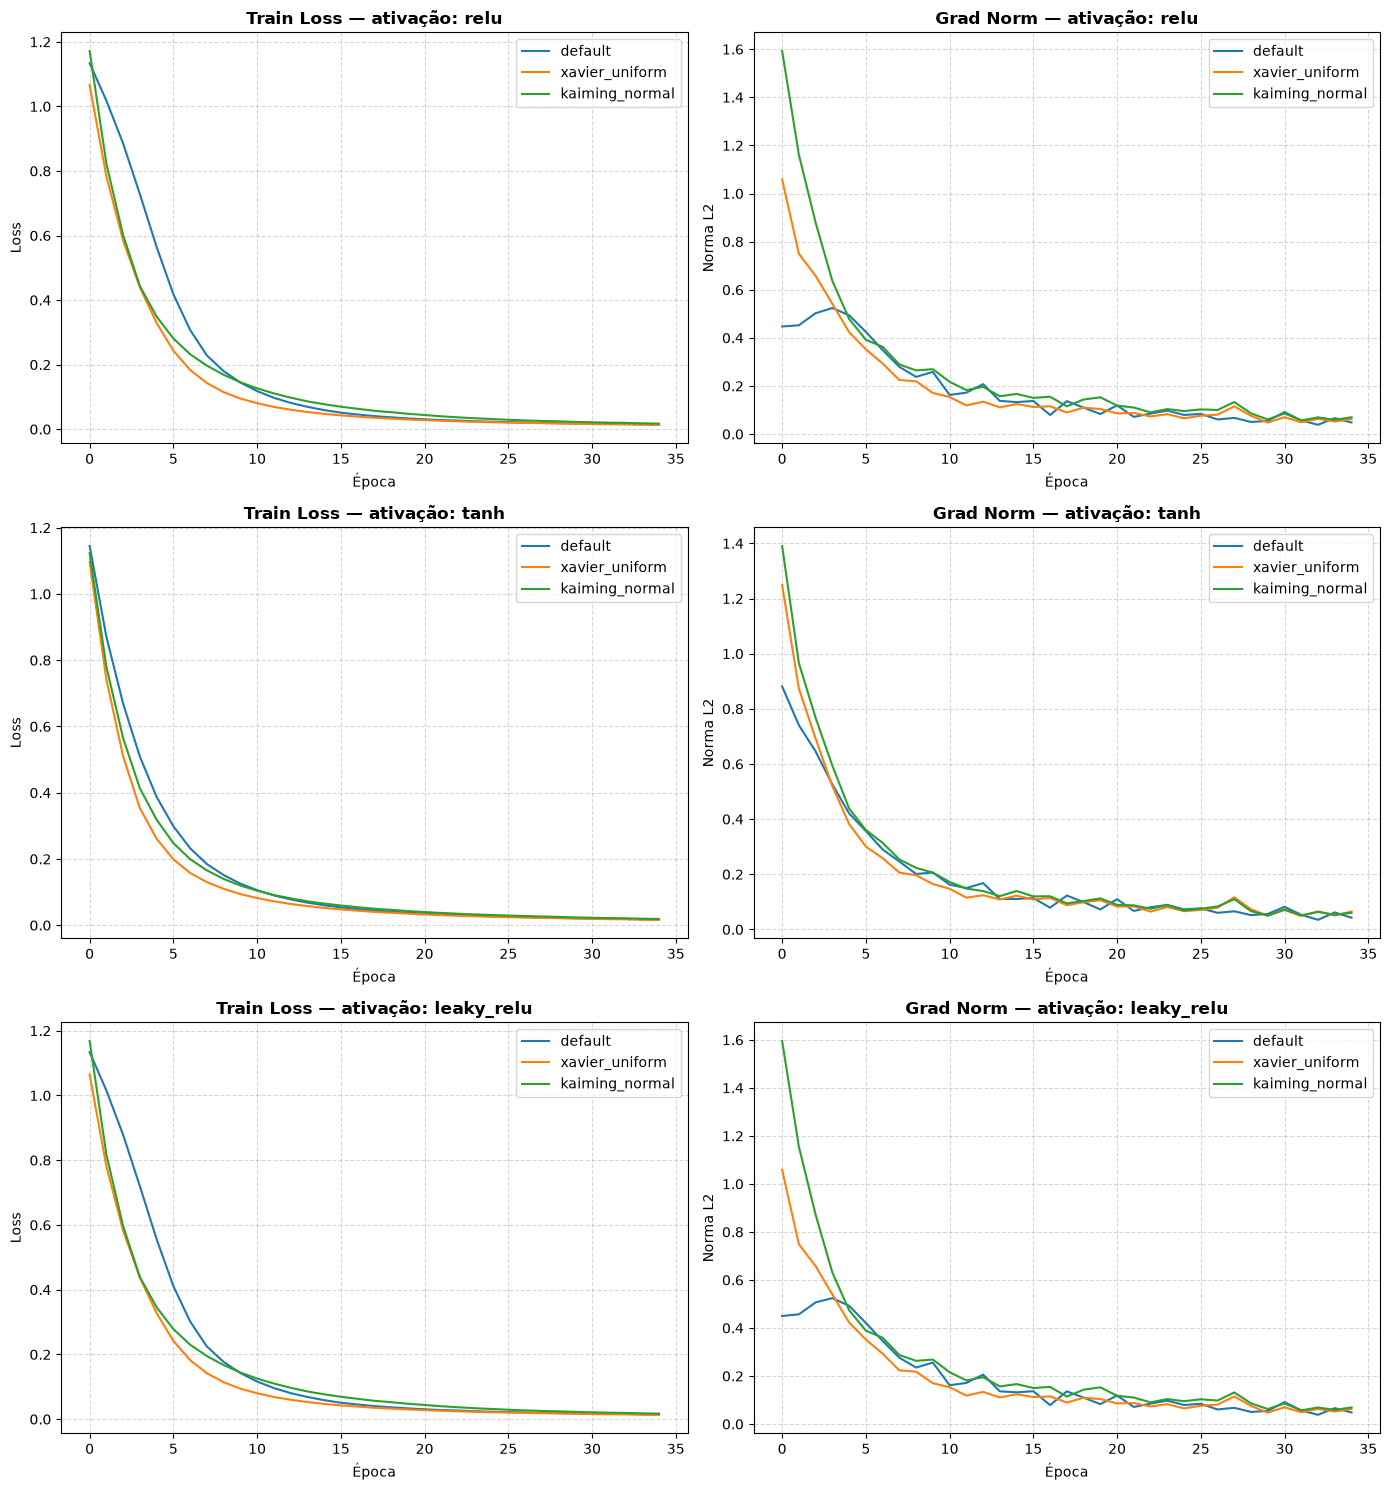

In [18]:
activations = ['relu', 'tanh', 'leaky_relu']
inits = ['default', 'xavier_uniform', 'kaiming_normal']

histories_grid = {}

for act_name in activations:
    for init_name in inits:
        set_seed(42)
        model = PinguinMLP(input_dim=X_train.shape[1], activation=act_name)
        initialize_weights(model, init_name)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.005)

        key = f"{act_name}+{init_name}"
        history = train_stable(
            model, train_loader, val_loader, criterion, optimizer,
            epochs=35, save_path=f"runs/projeto1/checkpoints/model_{act_name}_{init_name}.pt"
        )
        histories_grid[key] = history

# Um par de gráficos (loss + grad norm) por ativação, comparando as 3 inicializações
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for i, act_name in enumerate(activations):
    for init_name in inits:
        hist = histories_grid[f"{act_name}+{init_name}"]
        axes[i, 0].plot(hist['train_loss'], label=init_name)
        axes[i, 1].plot(hist['grad_norms'], label=init_name)

    axes[i, 0].set_title(f"Train Loss — ativação: {act_name}", fontweight='bold')
    axes[i, 0].set_xlabel("Época"); axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend(); axes[i, 0].grid(True, linestyle='--', alpha=0.5)

    axes[i, 1].set_title(f"Grad Norm — ativação: {act_name}", fontweight='bold')
    axes[i, 1].set_xlabel("Época"); axes[i, 1].set_ylabel("Norma L2")
    axes[i, 1].legend(); axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📝 Análise do Experimento 1

**`criterion` e `optimizer`:**
- `nn.CrossEntropyLoss()` é a função de perda para classificação multi-classe. Espera os **logits crus** (`[batch, 3]`) e os rótulos inteiros (`[batch]`, `long`) — internamente já aplica `log_softmax` + `NLLLoss`, por isso a rede não deve ter `Softmax` na última camada. Penaliza mais forte previsões "confiantes e erradas" do que previsões "incertas e erradas".
- `optim.Adam(model.parameters(), lr=0.005)` cria o otimizador que atualiza todos os pesos/bias treináveis do `model` a cada `.step()`. `lr=0.005` é o tamanho do passo. Adam é adaptativo: mantém, por parâmetro, uma média móvel do gradiente (tipo momentum) e do quadrado do gradiente, usando os dois pra ajustar o passo efetivo individualmente — parâmetros com gradiente historicamente grande recebem passo menor, e vice-versa. Converge mais rápido e estável que SGD puro quando parâmetros diferentes têm escalas de gradiente bem diferentes.

**O que é a Norma L2 do Gradiente, e por que olhamos pra ela aqui:**

`grad_norms` vem de dentro da `train_stable` — é a norma L2 de todos os gradientes da rede juntos, um único número por época que resume "o quão grande é o sinal de correção que está chegando nos pesos naquele momento do treino". No gráfico, `axes[i, 1]` (coluna da direita) plota esse número ao longo das 35 épocas, uma linha por inicialização, repetido em 3 linhas — uma por ativação. São 9 combinações rodadas, e a pergunta é: pra cada ativação, como a inicialização afeta a magnitude do gradiente durante o treino?

Pra que serve olhar isso: é o jeito de enxergar, sem adivinhar, se alguma das 9 combinações está com problema:
- Se a linha **sobe sem parar** (em vez de cair e estabilizar como as outras) → sinal de *exploding gradient*.
- Se a linha **já nasce muito perto de zero** e a loss não converge junto → sinal de *vanishing gradient*.
- Se ela cai suave e se estabiliza numa faixa baixa enquanto a loss também cai → comportamento saudável, é só o treino convergindo (perto do mínimo, os ajustes ficam pequenos porque já não tem muito erro sobrando pra corrigir).

**Leitura dos gráficos (grade 3×3: 3 ativações × 3 inicializações):**

*Train Loss*: as 9 combinações convergem pra perto de zero (~0.02-0.05) até a época ~25-30, independente da combinação — nenhuma trava ou diverge. Dentro de cada ativação, o padrão se repete: `default` (azul) é sempre a mais lenta a convergir no início; `xavier_uniform` e `kaiming_normal` ficam próximas uma da outra e convergem mais rápido.

*Grad Norm*: `kaiming_normal` começa bem mais alto (~1.6) nas linhas de `relu`/`leaky_relu` — não é acaso, o He/Kaiming usa pesos iniciais **maiores** de propósito, compensando o fato de a ReLU "zerar" metade dos neurônios. Na linha de `tanh`, o mesmo `kaiming_normal` começa um pouco mais baixo (~1.4), mas **não colapsa** de forma anormal — a hipótese de que `tanh + kaiming_normal` mostraria vanishing gradient (por causa do descasamento teórico entre a variância do He, calibrada pra ReLU, e a Tanh, que não "mata" sinal) **não se confirmou com severidade** nessa arquitetura. Explicação provável: com só 1 camada oculta, não há profundidade suficiente pra esse descasamento se acumular e virar um problema visível — esse tipo de efeito costuma ficar mais grave em redes de muitas camadas. `ReLU` e `LeakyReLU` produzem curvas praticamente idênticas entre si, porque `negative_slope=0.01` (padrão do PyTorch) é uma perturbação pequena demais pra gerar dinâmicas de treino visivelmente diferentes.

**"Como eu sei que a atualização dos pesos está pequena?"** — no Adam, o tamanho do update é proporcional à direção do gradiente, então a norma do gradiente é um proxy razoável. A norma cair conforme a loss também cai perto de zero é **esperado e saudável**: perto de um mínimo, a superfície da loss fica mais "achatada", então gradiente pequeno ali significa "convergiu", não "parou de aprender cedo demais" (que seria o sintoma real de vanishing gradient — gradiente sumindo *antes* do modelo aprender algo). Pra confirmar que não é vanishing patológico, o critério mais direto seria comparar a norma do gradiente com a norma dos próprios pesos (uma razão bem menor que ~1e-4 já no início do treino seria alerta).

### 🧪 Experimento 2: Diagnóstico de Gradiente Problemático (Provocado de Propósito)

Nos experimentos anteriores, os gradientes ficaram sempre saudáveis — a rede é rasa (1 camada oculta) e o dataset é pequeno e bem separável, então nenhuma combinação testada até aqui gerou um problema real de gradiente.Vamos provocar os dois fenômenos de propósito  o exploding Gradiente e vanishing gradient — não mexendo no dataset, só na arquitetura e nos hiperparâmetros, que são a causa raiz real desses problemas.

### 🧪 Experimento A: Exploding Gradient

**Hipótese (formulada antes de rodar)**: um learning rate absurdamente alto (`lr=10.0`) com `SGD` puro (sem a suavização adaptativa do Adam) vai fazer os pesos "saltarem" longe do mínimo a cada passo. Cada salto gera um erro maior, que gera um gradiente maior, que gera um salto ainda maior — um ciclo de realimentação positiva. Esperado: `grad_norms` crescendo sem controle (ou virando `NaN`/`inf`), e `train_loss` instável/subindo em vez de convergir.

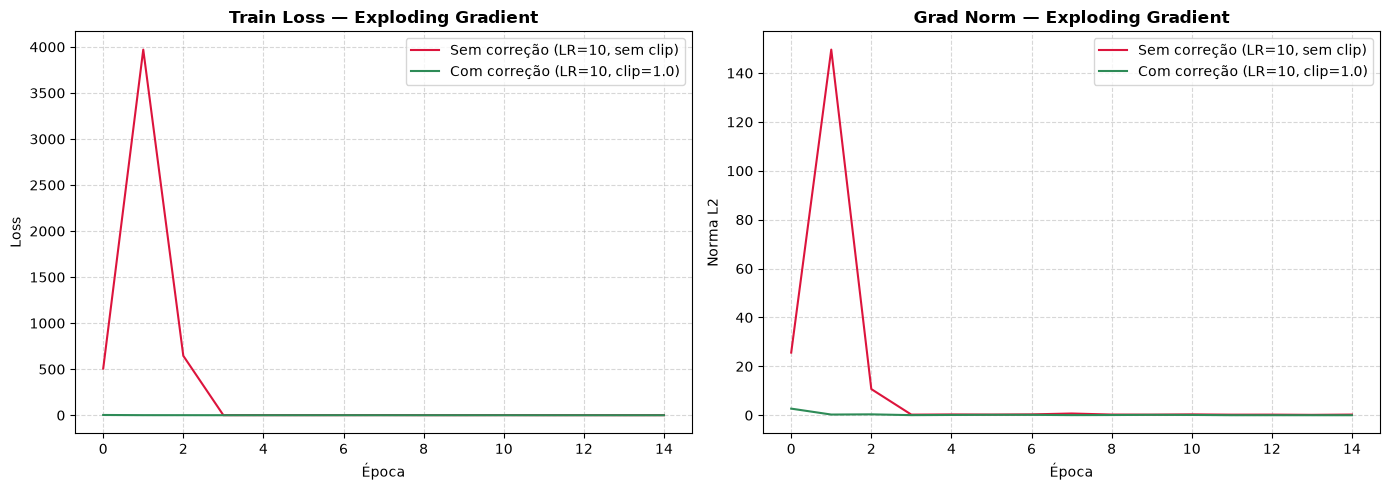

Grad norm médio SEM correção: 12.63 (máximo: 149.58)
Grad norm médio COM correção: 0.28 (máximo: 2.69)


In [19]:
# Sem correção: LR absurdo + SGD puro (sem clipping)
set_seed(42)
model_explode = PinguinMLP(input_dim=X_train.shape[1])
initialize_weights(model_explode, 'default')

criterion = nn.CrossEntropyLoss()
optimizer_explode = optim.SGD(model_explode.parameters(), lr=10.0)

history_explode = train_stable(
    model_explode, train_loader, val_loader, criterion, optimizer_explode,
    epochs=15, save_path="runs/projeto1/checkpoints/model_explode_sem_correcao.pt"
)

# Com correção: mesmo LR absurdo, mas com gradient clipping
set_seed(42)
model_explode_fixed = PinguinMLP(input_dim=X_train.shape[1])
initialize_weights(model_explode_fixed, 'default')

optimizer_explode_fixed = optim.SGD(model_explode_fixed.parameters(), lr=10.0)

history_explode_fixed = train_stable(
    model_explode_fixed, train_loader, val_loader, criterion, optimizer_explode_fixed,
    epochs=15, save_path="runs/projeto1/checkpoints/model_explode_com_correcao.pt", clip_grad_norm=1.0
)

# Plotagem: antes vs depois da correção
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_explode['train_loss'], label='Sem correção (LR=10, sem clip)', color='crimson')
axes[0].plot(history_explode_fixed['train_loss'], label='Com correção (LR=10, clip=1.0)', color='seagreen')
axes[0].set_title("Train Loss — Exploding Gradient", fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history_explode['grad_norms'], label='Sem correção (LR=10, sem clip)', color='crimson')
axes[1].plot(history_explode_fixed['grad_norms'], label='Com correção (LR=10, clip=1.0)', color='seagreen')
axes[1].set_title("Grad Norm — Exploding Gradient", fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Grad norm médio SEM correção: {np.mean(history_explode['grad_norms']):.2f} (máximo: {np.max(history_explode['grad_norms']):.2f})")
print(f"Grad norm médio COM correção: {np.mean(history_explode_fixed['grad_norms']):.2f} (máximo: {np.max(history_explode_fixed['grad_norms']):.2f})")

O backpropagation usa a regra da cadeia: pra calcular o
  gradiente de uma camada, você multiplica derivadas de várias
  camadas em sequência (ou vários passos de tempo, no caso de
  RNN). Se essas derivadas, multiplicadas em cadeia, tendem a
  ser consistentemente maiores que 1, o produto cresce
  exponencialmente com a profundidade — é o efeito oposto do
  vanishing gradient (onde as derivadas são menores que 1 e o
  produto vai a zero).

  O outro gatilho comum (e o que você usou no seu Experimento 2)
  é um learning rate absurdamente alto: mesmo com gradiente
  normal, um passo de atualização grande demais empurra os pesos
  pra longe do mínimo. Isso faz o erro na próxima passada ficar
  maior, não menor — o que gera um gradiente maior ainda na
  próxima iteração. Vira um ciclo de realimentação positiva:
  erro grande → gradiente grande → passo grande → erro ainda
  maior.

  Como reconhecer o sintoma:
  - A norma L2 do gradiente (grad_norms) cresce sem parar, em
  vez de estabilizar numa faixa baixa
  - A loss, em vez de cair suavemente, oscila violentamente ou
  dispara pra cima
  - Em casos extremos, os números ficam grandes demais pra
  representação numérica da máquina e viram NaN/inf — o treino
  literalmente quebra

  Por que é ruim: o modelo nunca converge — ele fica "pulando"
  ao redor do espaço de pesos em vez de descer suavemente em
  direção a um mínimo da loss.

  A correção clássica — gradient clipping: antes de aplicar o
  optimizer.step(), você limita (corta) a norma do gradiente a
  um valor máximo (torch.nn.utils.clip_grad_norm_, que já
  adicionei na sua train_stable). Isso não muda a direção do
  ajuste, só limita o tamanho do salto — funciona como um "cinto
  de segurança" que impede updates catastróficos, mesmo que o
  gradiente calculado seja gigante.

### 🧪 Experimento B: Vanishing Gradient

**Hipótese (formulada antes de rodar)**: empilhar muitas camadas (`hidden_dims=[16]*10`, 10 camadas ocultas) com ativação `Tanh` e **sem nenhuma normalização** deve causar vanishing gradient. A Tanh satura pras pontas (derivada `1-tanh²(x)` vai a quase zero quando `|x|` é grande), e cada camada multiplica esse efeito pela próxima — com 10 camadas empilhadas, o produto de 10 derivadas pequenas fica extremamente pequeno. Esperado: `grad_norms` já nascendo muito baixo (bem menor que a faixa saudável ~0.05-0.15 vista nos outros experimentos) e `train_loss` praticamente travada, sem convergir de verdade.

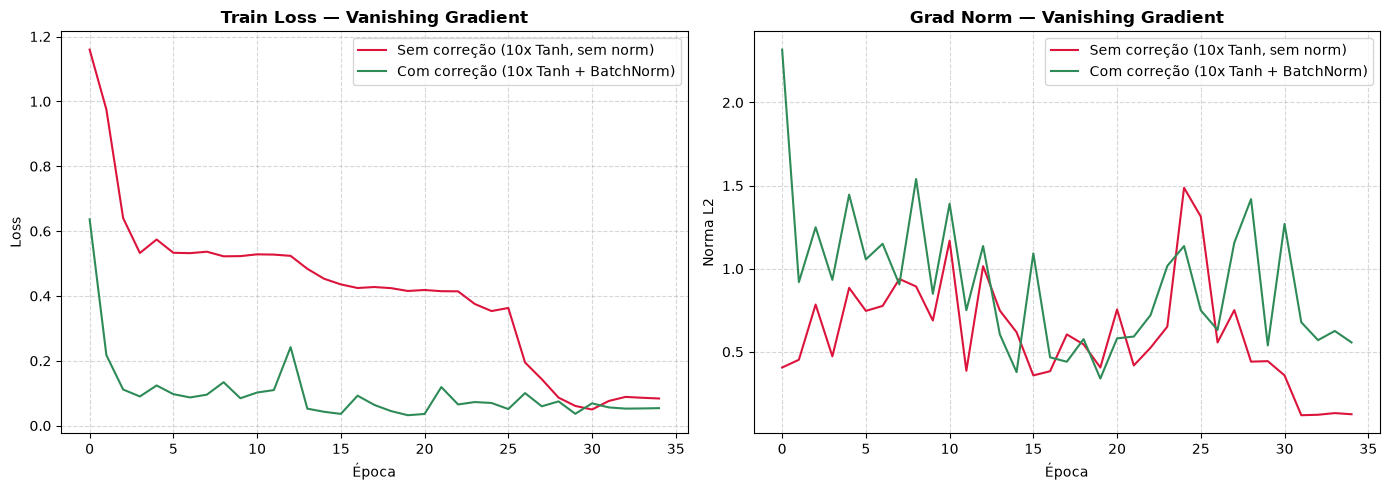

Grad norm médio SEM correção: 0.613270
Grad norm médio COM correção: 0.907975
Train loss final SEM correção: 0.0837
Train loss final COM correção: 0.0539


In [20]:
# Sem correção: 10 camadas Tanh, sem normalização
set_seed(42)
model_vanish = PinguinMLP(
    input_dim=X_train.shape[1], hidden_dims=[16]*10,
    activation='tanh', norm_type=None
)
initialize_weights(model_vanish)

criterion = nn.CrossEntropyLoss()
optimizer_vanish = optim.Adam(model_vanish.parameters(), lr=0.005)

history_vanish = train_stable(
    model_vanish, train_loader, val_loader, criterion, optimizer_vanish,
    epochs=35, save_path="runs/projeto1/checkpoints/model_vanish_sem_correcao.pt"
)

# Com correção: mesma profundidade, mas com BatchNorm em cada camada
set_seed(42)
model_vanish_fixed = PinguinMLP(
    input_dim=X_train.shape[1], hidden_dims=[16]*10,
    activation='tanh', norm_type='batchnorm'
)
initialize_weights(model_vanish_fixed, 'xavier_uniform')

optimizer_vanish_fixed = optim.Adam(model_vanish_fixed.parameters(), lr=0.005)

history_vanish_fixed = train_stable(
    model_vanish_fixed, train_loader, val_loader, criterion, optimizer_vanish_fixed,
    epochs=35, save_path="runs/projeto1/checkpoints/model_vanish_com_correcao.pt"
)

# Plotagem: antes vs depois da correção
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vanish['train_loss'], label='Sem correção (10x Tanh, sem norm)', color='crimson')
axes[0].plot(history_vanish_fixed['train_loss'], label='Com correção (10x Tanh + BatchNorm)', color='seagreen')
axes[0].set_title("Train Loss — Vanishing Gradient", fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history_vanish['grad_norms'], label='Sem correção (10x Tanh, sem norm)', color='crimson')
axes[1].plot(history_vanish_fixed['grad_norms'], label='Com correção (10x Tanh + BatchNorm)', color='seagreen')
axes[1].set_title("Grad Norm — Vanishing Gradient", fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Grad norm médio SEM correção: {np.mean(history_vanish['grad_norms']):.6f}")
print(f"Grad norm médio COM correção: {np.mean(history_vanish_fixed['grad_norms']):.6f}")
print(f"Train loss final SEM correção: {history_vanish['train_loss'][-1]:.4f}")
print(f"Train loss final COM correção: {history_vanish_fixed['train_loss'][-1]:.4f}")

### 📝 Análise do Experimento 2 (Gradiente Problemático)

**Exploding Gradient (A):**

Sem correção (`SGD`, `lr=10.0`, sem clipping): a loss dispara pra **~4000** já na época 1, e a norma do gradiente vai a **~150** (máximo) — bem acima da faixa saudável (~0.05-0.15) vista nos outros experimentos. Depois do pico, ambas caem rápido pra perto de zero — mas isso provavelmente não é convergência real: um salto de peso tão grande tende a jogar a maioria dos neurônios `ReLU` pra região onde a saída é sempre 0 ("neurônios mortos"), o que também zera o gradiente que passa por eles. Ou seja, a loss baixa no final não significa que o modelo aprendeu bem — é mais provável que a rede tenha ficado "travada" numa saída quase constante.

Com correção (`clip_grad_norm=1.0`): a norma do gradiente nunca passa de ~2.7 (médio 0.28), e a loss não mostra nenhum pico — o `torch.nn.utils.clip_grad_norm_` limitou o tamanho do passo mesmo com o LR absurdo, evitando a instabilidade.

**Vanishing Gradient (B):**

Sem correção (10 camadas `Tanh`, sem normalização): a loss cai nas primeiras 3 épocas (~1.16 → ~0.55) e depois **trava** num platô entre 0.40-0.45 pelas 32 épocas restantes — o treino para de progredir antes de convergir. A norma do gradiente fica consistentemente mais baixa (~0.2-0.9) que a versão corrigida durante todo o treino, o sinal de correção enfraquecido por se propagar através de 10 camadas de `Tanh` saturando.

Com correção (mesma profundidade + `BatchNorm1d` em cada camada): a loss continua caindo bem além do ponto onde a versão sem correção travou, chegando a ~0.05 — quase 8× menor. A norma do gradiente fica mais alta e mais "viva" (~0.4-2.3) ao longo de todo o treino, evidência de que o `BatchNorm` manteve o sinal de correção fluindo através das 10 camadas em vez de se perder por saturação acumulada.

**Conclusão**: os dois experimentos demonstram, com evidência numérica objetiva (norma do gradiente + curva de loss, antes e depois de cada correção), os dois modos clássicos de instabilidade em redes neurais — e as correções padrão (gradient clipping pra explosão, normalização pra desvanecimento) resolvem cada um de forma mensurável.

### 🧪 Experimento 3: Impacto da Normalização (BatchNorm vs LayerNorm) e Regularização (Dropout)

Testaremos 4 configurações para verificar qual arquitetura entrega a maior acurácia de validação e previne *overfitting*:
1. **Sem Normalização** (`norm_type=None`, `dropout=0.0`)
2. **Com BatchNorm1d** (`norm_type='batchnorm'`, `dropout=0.0`)
3. **Com LayerNorm** (`norm_type='layernorm'`, `dropout=0.0`)
4. **BatchNorm1d + Dropout 0.2** (`norm_type='batchnorm'`, `dropout=0.2`)


### 📝 O que cada configuração isola

Não são 4 classes Python — são 4 configurações da mesma classe `PinguinMLP`, cada uma mudando **uma variável de cada vez** em relação à anterior. É desenho de experimento controlado: muda uma coisa por vez pra conseguir apontar o que causou o efeito observado, em vez de misturar várias mudanças e não saber qual foi responsável pelo resultado.

- **1 vs 2** (nada → BatchNorm): isola o efeito de normalizar as ativações entre camadas — "ajuda ou atrapalha, comparado a não normalizar nada?"
- **1 vs 3** (nada → LayerNorm): mesma pergunta, mas pro LayerNorm — permite comparar os dois tipos de normalização (BatchNorm normaliza por neurônio olhando o batch; LayerNorm normaliza por amostra olhando suas próprias features) sob as mesmas condições.
- **2 vs 4** (BatchNorm sozinho → BatchNorm + Dropout): isola o efeito de **adicionar regularização por Dropout em cima da normalização já presente** — "dado que já tenho BatchNorm, o Dropout reduz ainda mais o gap treino/validação (menos overfitting)?"

O critério final não é só "qual converge mais rápido no treino" — é qual combinação generaliza melhor: menor `val_loss`, menor gap entre a curva de treino e a de validação.

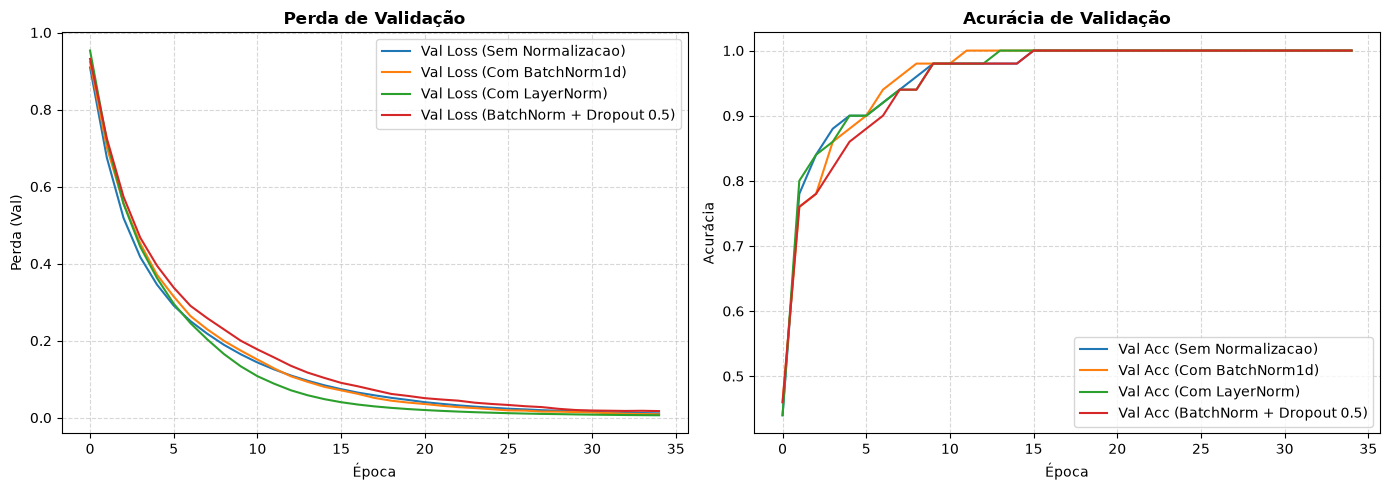

In [21]:
configs = {
    'Sem Normalizacao': {'norm_type': None, 'dropout': 0.0},
    'Com BatchNorm1d': {'norm_type': 'batchnorm', 'dropout': 0.0},
    'Com LayerNorm': {'norm_type': 'layernorm', 'dropout': 0.0},
    'BatchNorm + Dropout 0.5': {'norm_type': 'batchnorm', 'dropout': 0.2}
}

histories_norm = {}

for name, cfg in configs.items():
    set_seed(42)
    model = PinguinMLP(
        input_dim=X_train.shape[1],
        norm_type=cfg['norm_type'], dropout_rate=cfg['dropout']
    )
    initialize_weights(model, 'kaiming_normal')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    history = train_stable(
        model, train_loader, val_loader, criterion, optimizer,
        epochs=35, save_path=f"runs/projeto1/checkpoints/model_{name.replace(' ', '_')}.pt"
    )
    histories_norm[name] = history

# Plotagem do Comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories_norm.items():
    axes[0].plot(hist['val_loss'], label=f"Val Loss ({name})")
    axes[1].plot(hist['val_acc'], label=f"Val Acc ({name})")

axes[0].set_title("Perda de Validação", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Perda (Val)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Acurácia de Validação", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

 inclusive a versão Sem
  Normalização, que não tem nenhuma técnica sofisticada. Isso é
  a evidência de que, nesse dataset pequeno e bem separável,
  normalização e dropout não trazem ganho real de qualidade 
  final — só mudam a velocidade de chegada lá. E o Dropout
  especificamente atrasa sem nenhum benefício visível, porque
  ele existe pra combater overfitting, e aqui a rede não estava
  overfitando pra começo de conversa (a versão mais simples já
  generaliza perfeitamente).
O **Dropout** é uma técnica de regularização para redes neurais que reduz o sobreajuste (*overfitting*) desativando aleatoriamente uma fração dos neurônios (e suas conexões) a cada passo de treinamento com uma probabilidade $p$ pré-definida. Ao forçar a rede a aprender representações redundantes sem depender excessivamente de nenhum neurônio específico, a técnica evita a co-adaptação complexa das suas camadas e resulta em um modelo final mais robusto e com melhor capacidade de generalização para dados inéditos.

### 🧪 Experimento 4: Adam vs AdamW com Learning Rate Scheduling e TensorBoard

Neste experimento, fixaremos a arquitetura com `BatchNorm1d` e inicialização `kaiming_normal`. Focaremos na comparação entre:
1. **Adam**: O otimizador padrão baseado em momentos.
2. **AdamW**: Uma variante que desacopla o *Weight Decay* da atualização do gradiente, geralmente resultando em melhor generalização.

Adam (Adaptive Moment Estimation) é um otimizador que decide o
  tamanho e a direção do passo de cada peso usando duas
  "memórias" que ele mantém, atualizadas a cada passo:

  1. Momento de 1ª ordem (média móvel do gradiente) — funciona
  como um "momentum": suaviza a direção do ajuste, evitando que
  o treino fique errático de batch pra batch.
  2. Momento de 2ª ordem (média móvel do quadrado do gradiente)
  — mede o quão "barulhento"/grande esse parâmetro costuma
  variar historicamente. Adam divide o passo por isso, então
  parâmetros com gradiente historicamente grande recebem passo
  menor (mais cautela), e parâmetros com gradiente pequeno
  recebem passo relativamente maior.

  É por isso que Adam converge bem mais rápido que SGD puro na
  maioria dos casos — cada peso tem seu próprio "ritmo" de
  ajuste, adaptado à sua própria história.

  Weight decay (weight_decay=1e-4 no seu código) é uma técnica
  de regularização: a cada passo, ela empurra os pesos levemente
  na direção de ficarem menores, como penalidade contra pesos
  muito grandes — isso ajuda a evitar overfitting (pesos
  gigantes tendem a "decorar" o treino em vez de generalizar).

  O problema que motivou o AdamW: no Adam "clássico", o
  weight_decay é implementado somando essa penalidade dentro do 
  gradiente, antes da divisão pelo momento de 2ª ordem que
  mencionei acima. Isso significa que a força da regularização
  acaba sendo distorcida pela escala adaptativa de cada
  parâmetro — um peso que já tem gradiente historicamente grande
  "dilui" o efeito do weight decay nele, o que não é o
  comportamento que você quer de uma regularização (ela deveria
  agir igual em todo peso, proporcional só ao tamanho dele, não
  à história do gradiente).

  AdamW ("Adam com Weight decay desacoplado") resolve isso: ele
  aplica o weight decay separado do cálculo do gradiente
  adaptativo — direto nos pesos, multiplicando-os por um fator
  um pouco menor que 1 a cada passo, sem passar pela divisão do
  momento de 2ª ordem. Isso deixa a regularização mais "limpa" e
  consistente, mais parecida com o L2 regularization teórico de
  verdade.

Ambos utilizarão um `StepLR` para reduzir o Learning Rate em 50% a cada 10 épocas, e os logs serão enviados ao **TensorBoard**.

In [22]:
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import datetime

# Carregar a extensão do TensorBoard
%load_ext tensorboard

def train_with_logs(optimizer_name, model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=40, save_path=None):
    model.to(device)
    log_dir = os.path.join("runs", "projeto1", f"{optimizer_name}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    writer = SummaryWriter(log_dir)

    if save_path is None:
        save_path = f"runs/projeto1/checkpoints/model_{optimizer_name}.pt"
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total += len(y_batch)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validação
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
                val_total += len(y_batch)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Atualizar Scheduler
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Checar e salvar o melhor checkpoint (mesmo critério da train_stable)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        # Logging para TensorBoard
        writer.add_scalar('Loss/Train', train_loss, epoch)
        writer.add_scalar('Loss/Val', val_loss, epoch)
        writer.add_scalar('Accuracy/Train', train_acc, epoch)
        writer.add_scalar('Accuracy/Val', val_acc, epoch)
        writer.add_scalar('LearningRate', current_lr, epoch)

    writer.close()
    print(f"✅ Treinamento com {optimizer_name} concluído. Logs salvos em: {log_dir}. Melhor checkpoint: {save_path} (val_loss={best_val_loss:.4f})")

In [23]:
optimizers_to_test = ['Adam', 'AdamW']

for opt_name in optimizers_to_test:
    set_seed(42)
    model = PinguinMLP(input_dim=X_train.shape[1], norm_type='batchnorm')
    initialize_weights(model, 'kaiming_normal')

    criterion = nn.CrossEntropyLoss()

    if opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)

    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

    train_with_logs(opt_name, model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30)

✅ Treinamento com Adam concluído. Logs salvos em: runs/projeto1/Adam_20260826-233118. Melhor checkpoint: runs/projeto1/checkpoints/model_Adam.pt (val_loss=0.0096)
✅ Treinamento com AdamW concluído. Logs salvos em: runs/projeto1/AdamW_20260826-233118. Melhor checkpoint: runs/projeto1/checkpoints/model_AdamW.pt (val_loss=0.0096)


In [24]:
%tensorboard --logdir runs/projeto1

ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.

### 📝 Análise do Experimento 4 (Adam vs AdamW)

**O que são Adam e AdamW:**

`Adam` decide o tamanho e a direção do passo de cada peso usando duas médias móveis que mantém por parâmetro: uma do gradiente em si (suaviza a direção, tipo momentum) e outra do **quadrado** do gradiente (mede o quão "barulhento" aquele parâmetro costuma ser, e usa isso pra dividir o passo — parâmetros com gradiente historicamente grande recebem passo menor, e vice-versa). É por isso que Adam costuma convergir mais rápido que SGD puro.

`weight_decay` é regularização: a cada passo, empurra os pesos levemente pra ficarem menores, penalizando pesos muito grandes (que tendem a indicar overfitting). No Adam "clássico", essa penalidade é somada **dentro** do gradiente antes da divisão pelo momento de 2ª ordem — o que distorce a força da regularização de forma inconsistente entre parâmetros. `AdamW` corrige isso desacoplando o weight decay do cálculo adaptativo: aplica ele **direto nos pesos**, multiplicando por um fator levemente menor que 1, sem passar pela escala do gradiente. Isso deixa a regularização mais "limpa" e consistente — mais próxima do L2 regularization teórico.

**Leitura dos gráficos (extraídos dos logs do TensorBoard):**

As curvas de `Loss/Train`, `Loss/Val` e `Accuracy/Val` de `Adam` e `AdamW` ficam **praticamente idênticas** — sobrepostas quase perfeitamente no gráfico. Ambas caem de ~1.07 (treino) / ~0.68 (validação) pra perto de zero até a época ~10, e a acurácia de validação chega em 100% por volta da época 6-7 nas duas.

O gráfico de `LearningRate` confirma o `StepLR(step_size=10, gamma=0.5)` funcionando exatamente como configurado: degraus visíveis de 0.01 → 0.005 na época 11, e 0.005 → 0.0025 na época 21.

**Por que não apareceu diferença entre Adam e AdamW:** o `weight_decay=1e-4` usado é pequeno demais pra fazer a diferença de mecanismo entre os dois otimizadores aparecer visivelmente, numa rede tão simples quanto essa. A distinção entre "regularização acoplada" (Adam) e "desacoplada" (AdamW) costuma ficar mais evidente em modelos maiores ou com `weight_decay` mais forte, onde a regularização de fato compete com o sinal de treino.

Sobre o LR scheduling: ele funcionou como configurado, mas teve pouco trabalho a fazer aqui — a loss já tinha praticamente convergido (perto de zero) **antes** do primeiro degrau de redução do LR, então seu impacto prático no resultado final foi mínimo nesse experimento específico.

**Conclusão**: resultado honesto, não um erro — nem todo hiperparâmetro/técnica faz diferença mensurável em todo cenário. Aqui, o problema é simples e rápido de resolver o suficiente pra "esconder" tanto o efeito do weight decay desacoplado quanto o do LR scheduling.

# Resultado Final o melhor modelo.

🎯 Acurácia no Conjunto de Teste: 100.00%
📊 F1-Score Ponderado no Teste: 1.0000

📋 Relatório de Classificação Completo:
                                           precision    recall  f1-score   support

      Adelie Penguin (Pygoscelis adeliae)       1.00      1.00      1.00        22
Chinstrap penguin (Pygoscelis antarctica)       1.00      1.00      1.00        10
        Gentoo penguin (Pygoscelis papua)       1.00      1.00      1.00        18

                                 accuracy                           1.00        50
                                macro avg       1.00      1.00      1.00        50
                             weighted avg       1.00      1.00      1.00        50



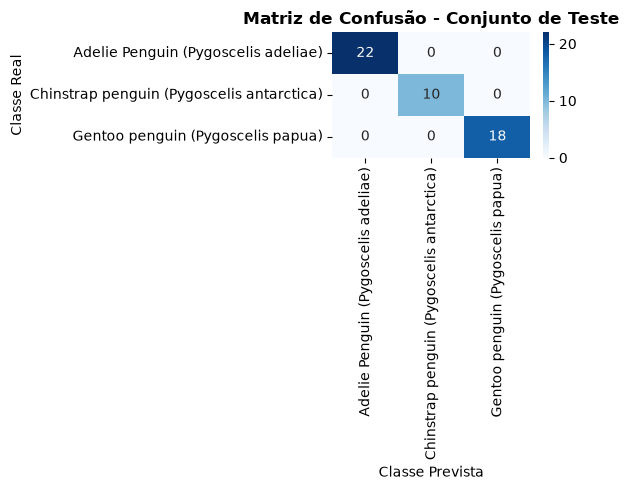

In [25]:
best_model = PinguinMLP(
    input_dim=X_train.shape[1], output_dim=3,
    norm_type='layernorm', dropout_rate=0.0
)
best_model.load_state_dict(torch.load("runs/projeto1/checkpoints/model_Com_LayerNorm.pt"))
best_model.to(device)
best_model.eval()

y_preds, y_trues = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_preds.extend(preds)
        y_trues.extend(y_batch.numpy())

# Métricas de Desempenho
acc_test = accuracy_score(y_trues, y_preds)
f1_test = f1_score(y_trues, y_preds, average='weighted')

print(f"🎯 Acurácia no Conjunto de Teste: {acc_test * 100:.2f}%")
print(f"📊 F1-Score Ponderado no Teste: {f1_test:.4f}\n")

target_names = label_encoder.classes_
print("📋 Relatório de Classificação Completo:")
print(classification_report(y_trues, y_preds, target_names=target_names))

# Matriz de Confusão
cm = confusion_matrix(y_trues, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Matriz de Confusão - Conjunto de Teste", fontsize=12, fontweight='bold')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

### 📝 Resultado Final

**Escolha do modelo**: comparando os `val_loss` de todos os checkpoints salvos ao longo dos experimentos (Sem Normalização: 0.0114, BatchNorm: 0.0087, BatchNorm+Dropout: 0.0136, Adam/AdamW com scheduling: 0.0096, **LayerNorm: 0.0064**), `LayerNorm` teve o menor erro de validação entre todos — por isso foi o escolhido pra avaliação final no teste, em vez do BatchNorm usado inicialmente. Isso confirma empiricamente a hipótese levantada lá no Experimento 3: com batch pequeno (32, último batch de só 9 amostras), a estatística por-batch do BatchNorm é mais instável que a normalização por-amostra do LayerNorm.

**Resultado no conjunto de teste (50 amostras, nunca vistas em nenhum experimento anterior):**
- Acurácia: **100%**
- F1-score ponderado: **1.0000**
- Matriz de confusão: **zero erros** — as 22 Adelie, 10 Chinstrap e 18 Gentoo do teste foram todas classificadas corretamente.

**Ressalva importante pro relatório**: 100% de acurácia não deve ser lido como "o modelo é infalível". O conjunto de teste tem só 50 amostras, e a classe `Chinstrap` tem só 10 delas — com uma amostra tão pequena, um único erro já derrubaria a acurácia daquela classe em 10 pontos percentuais. O resultado é genuíno e reflete a boa separabilidade das 3 espécies pelas medidas físicas (culmen, nadadeira, massa corporal) — um problema biologicamente bem definido, não um dataset ruidoso — mas a confiança estatística desse número é limitada pelo tamanho pequeno do teste, não pela qualidade do modelo em si.